# Marketing Budget Optimization using Linear Regression

## Business Problem
A company spends money on different marketing channels such as TV, Radio, Social Media, and Digital Ads.  
The company wants to understand which channels generate the highest sales and how the marketing budget should be optimized.

This project uses Linear Regression to:
- Analyze marketing spend data
- Understand relationships between channels and sales
- Build a predictive regression model
- Evaluate marketing effectiveness
- Recommend budget allocation strategies

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

In [3]:
df= pd.read_csv('/content/part_4_marketing_budget_optimization.csv')

# Dataset Understanding

The dataset contains marketing spending across different channels.

Possible columns:
- TV Spend
- Radio Spend
- Social Media Spend
- Digital Spend
- Sales / Revenue

Independent Variables:
- TV
- Radio
- Social Media
- Digital

Dependent Variable:
- Sales

In [4]:
df.head()

,CampaignID,Month,Region,TV_Spend,Radio_Spend,SocialMedia_Spend,SearchAds_Spend,Influencer_Spend,Sales_Revenue
0,MKT0001,2023-01,East,70.02,14.67,31.74,35.44,6.99,408.48
1,MKT0002,2023-03,North,22.97,10.39,34.81,39.11,0.37,365.55
2,MKT0003,2023-04,Central,40.01,5.02,43.38,13.38,19.44,336.59
3,MKT0004,2023-05,North,40.84,37.61,15.26,30.91,13.76,409.73
4,MKT0005,2023-05,South,39.63,23.68,55.48,33.00,29.38,407.32


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 420 entries, 0 to 419
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CampaignID         420 non-null    object 
 1   Month              420 non-null    object 
 2   Region             420 non-null    object 
 3   TV_Spend           420 non-null    float64
 4   Radio_Spend        420 non-null    float64
 5   SocialMedia_Spend  416 non-null    float64
 6   SearchAds_Spend    420 non-null    float64
 7   Influencer_Spend   420 non-null    float64
 8   Sales_Revenue      420 non-null    float64
dtypes: float64(6), object(3)
memory usage: 29.7+ KB


In [6]:
df.describe

<bound method NDFrame.describe of     CampaignID    Month   Region  TV_Spend  Radio_Spend  SocialMedia_Spend  \
0      MKT0001  2023-01     East     70.02        14.67              31.74   
1      MKT0002  2023-03    North     22.97        10.39              34.81   
2      MKT0003  2023-04  Central     40.01         5.02              43.38   
3      MKT0004  2023-05    North     40.84        37.61              15.26   
4      MKT0005  2023-05    South     39.63        23.68              55.48   
..         ...      ...      ...       ...          ...                ...   
415    MKT0416  2023-08    South     68.54        20.67              29.47   
416    MKT0417  2023-09     East     57.00        27.26              12.15   
417    MKT0418  2023-10     East     76.51        39.69               7.47   
418    MKT0419  2023-11  Central     72.51        20.04              40.05   
419    MKT0420  2023-12     East     50.02        19.74              43.41   

     SearchAds_Spend  Influencer_Spend  Sales_Revenue  
0              35.44              6.99         408.48  
1              39.11              0.37         365.55  
2              13.38             19.44         336.59  
3              30.91             13.76         409.73  
4              33.00             29.38         407.32  
..               ...               ...            ...  
415            48.54             18.30         518.86  
416            42.63              0.72         450.52  
417            26.44             12.84         514.04  
418            27.52              4.71         452.47  
419            42.58              4.16         438.54  

[420 rows x 9 columns]>

In [7]:
df.isnull().sum()

,0
CampaignID,0
Month,0
Region,0
TV_Spend,0
Radio_Spend,0
SocialMedia_Spend,4
SearchAds_Spend,0
Influencer_Spend,0
Sales_Revenue,0


In [8]:
df.duplicated().sum()

np.int64(0)

# Data Cleaning

The following checks were performed:
- Missing value check
- Duplicate record check
- Data type verification
- Outlier inspection

The dataset was cleaned before model building.



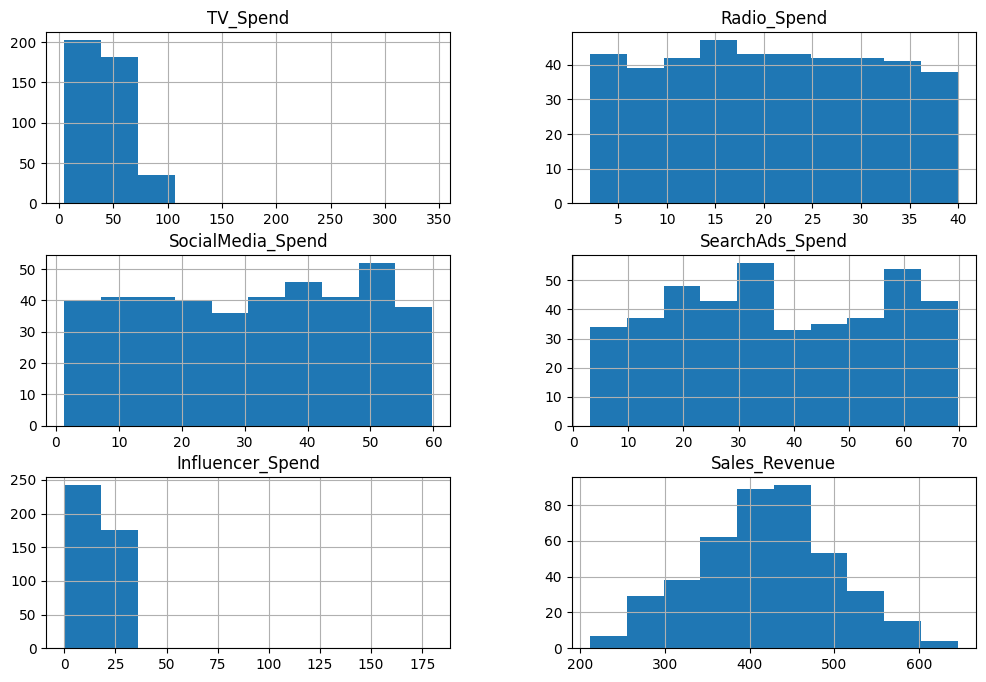

In [9]:
df.hist(figsize=(12, 8))
plt.show()

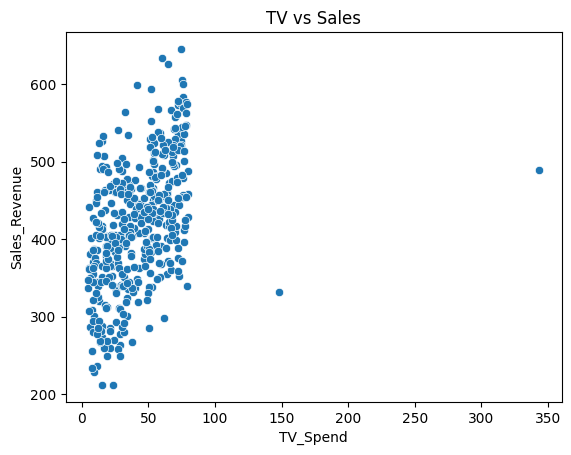

In [17]:
sns.scatterplot(x=df['TV_Spend'], y=df['Sales_Revenue'])
plt.title('TV vs Sales')
plt.show()

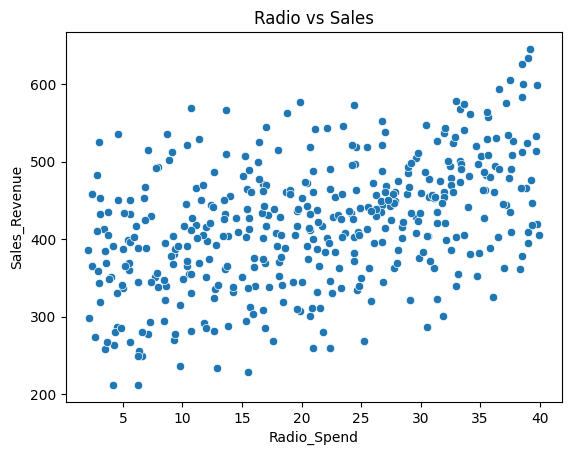

In [18]:
sns.scatterplot(x=df['Radio_Spend'], y=df['Sales_Revenue'])
plt.title('Radio vs Sales')
plt.show()

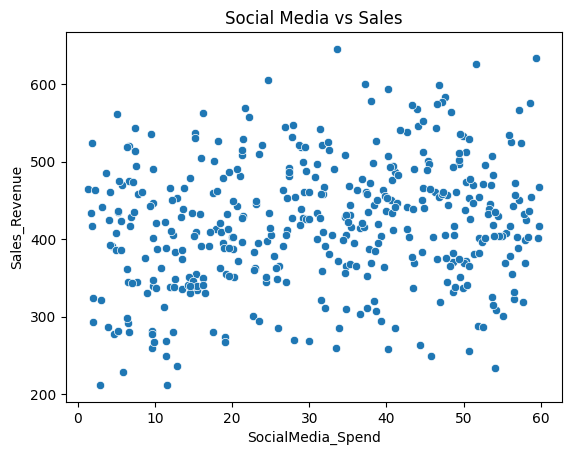

In [19]:
sns.scatterplot(x=df['SocialMedia_Spend'], y=df['Sales_Revenue'])
plt.title('Social Media vs Sales')
plt.show()

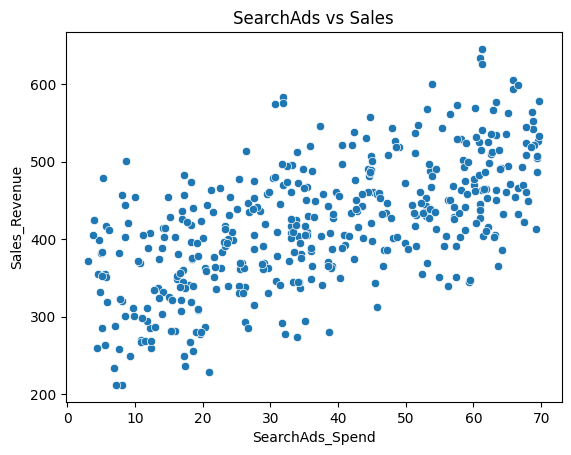

In [21]:
sns.scatterplot(x=df['SearchAds_Spend'], y=df['Sales_Revenue'])
plt.title('SearchAds vs Sales')
plt.show()

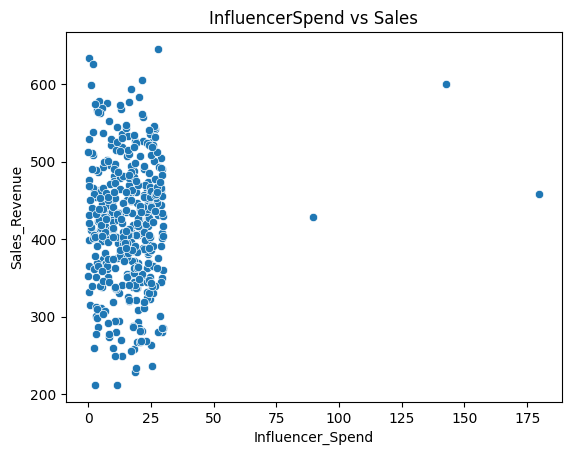

In [23]:
sns.scatterplot(x=df['Influencer_Spend'], y=df['Sales_Revenue'])
plt.title('InfluencerSpend vs Sales')
plt.show()

# Exploratory Data Analysis

Observations:
- TV spending shows a positive relationship with sales.
- Radio advertising also contributes positively.
- Social Media and Digital marketing impact can be observed through scatterplots.
- Higher marketing spending generally increases sales.

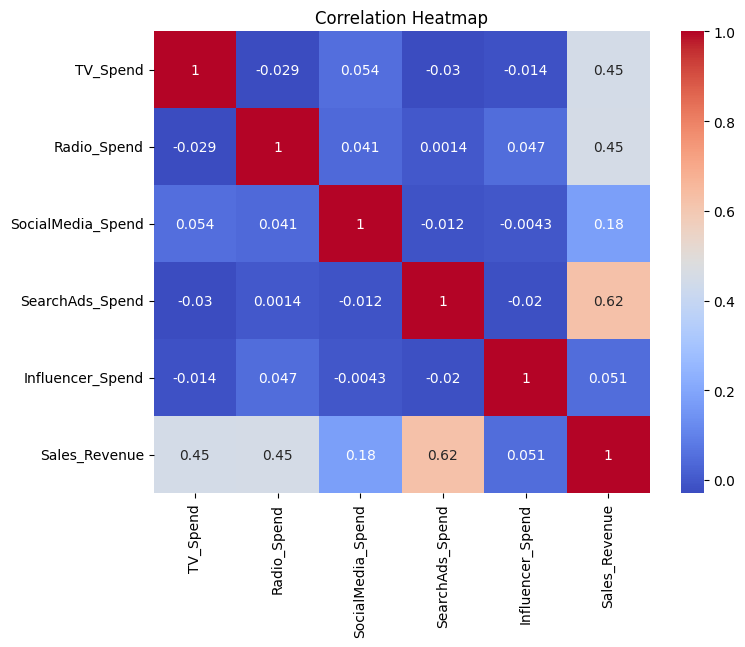

In [26]:
numeric_df = df.select_dtypes(include=['number'])

plt.figure(figsize=(8,6))

sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm')

plt.title('Correlation Heatmap')

plt.show()

In [28]:
X=df[['TV_Spend','Radio_Spend','SocialMedia_Spend','SearchAds_Spend','Influencer_Spend']]
y=df['Sales_Revenue']

In [29]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [33]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

# Remove missing values
df = df.dropna()

# Features and target
X = df[['TV_Spend','Radio_Spend','SocialMedia_Spend',
        'SearchAds_Spend','Influencer_Spend']]

y = df['Sales_Revenue']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Model training
model = LinearRegression()

model.fit(X_train, y_train)

print("Model trained successfully")

Model trained successfully


In [34]:
y_pred = model.predict(X_test)


# Model Evaluation

The model is evaluated using:
- MAE
- MSE
- RMSE
- R² Score

In [35]:
mae = mean_absolute_error(y_test, y_pred)

mse = mean_squared_error(y_test, y_pred)

rmse = np.sqrt(mse)

r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("MSE:", mse)
print("RMSE:", rmse)
print("R2 Score:", r2)

MAE: 24.080881637223257
MSE: 1144.8276750825858
RMSE: 33.835302201732816
R2 Score: 0.8554081725743832


In [38]:
coefficients = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model.coef_
})

coefficients

,Feature,Coefficient
0,TV_Spend,1.383624
1,Radio_Spend,3.435948
2,SocialMedia_Spend,0.668668
3,SearchAds_Spend,2.646730
4,Influencer_Spend,0.221113


# Coefficient Interpretation

Positive coefficient:
- Increase in spending increases sales.

Negative coefficient:
- Increase in spending decreases sales.

Channels with larger positive coefficients have stronger impact on revenue.

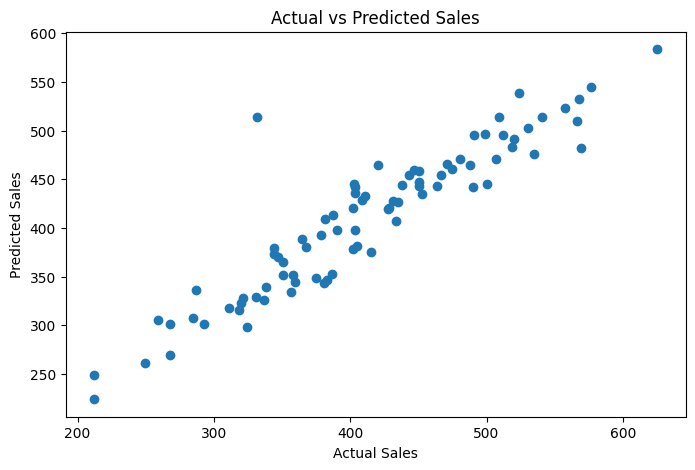

In [40]:
plt.figure(figsize=(8,5))

plt.scatter(y_test, y_pred)

plt.xlabel('Actual Sales')

plt.ylabel('Predicted Sales')

plt.title('Actual vs Predicted Sales')

plt.show()

# ROI and Channel Effectiveness

Marketing channels were analyzed based on:
- Contribution to sales
- Regression coefficients
- Correlation with revenue

Channels with stronger coefficients are considered more effective.

# Budget Recommendation

Based on the regression analysis:

- Increase budget for channels with high positive coefficients.
- Reduce investment in low-performing channels.
- Focus more on channels generating strong sales relationships.
- Continuously monitor campaign performance.
- Use data-driven budget allocation strategies.

# Conclusion

This project analyzed marketing spend data using Linear Regression.

Key achievements:
- Cleaned and explored the dataset
- Identified relationships between marketing channels and sales
- Built a predictive regression model
- Evaluated model performance
- Recommended marketing budget optimization strategies

The project helps businesses make informed marketing decisions using data analytics.